# Exploration / Exploitation — compare algorithms

Reads the per-iteration `diversity_{seed}.csv` files (produced by the benchmark
rerun with `-e`) straight from the `outputs/` tree and plots exploration /
exploitation curves so you can compare how algorithms balance searching vs
converging over a run.

Unlike the entropy/return-rate notebooks there's no single cached CSV - the
diversity data lives in many small files at
`outputs/dim_{d}/{alg}/{f}_{i}/diversity_{seed}.csv`, so the loader below
assembles just the curves you ask for.

**Prerequisite:** the benchmark rerun with `-e` must have populated the tree.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

OUTPUTS_DIR = "outputs"

# ---- knobs ----
DIM = 10
F, I = 23, 1          # which problem / instance (folders are bare ints: f_i)
RUNS = [1, 2, 3, 4, 5]

# algorithms to compare - pick a handful. A DE-family sanity set + a couple of
# contrasting ones is a good default.
ALGOS = ["JADE", "OriginalDE", "SADE", "OriginalWOA", "OriginalGWO", "AugmentedAEO"]

In [24]:
def load_diversity(dim, alg, f, i, seed):
    path = f"{OUTPUTS_DIR}/dim_{dim}/{alg}/{f}_{i}/diversity_{seed}.csv"
    if not os.path.isfile(path):
        return None
    return pd.read_csv(path).sort_values('iteration')

def load_curves(dim, algos, f, i, runs):
    """Long-format frame: algorithm, run, iteration, diversity, exploration, exploitation."""
    frames = []
    for alg in algos:
        for seed in runs:
            df = load_diversity(dim, alg, f, i, seed)
            if df is None:
                print(f"  missing: {alg} f{f} i{i} seed{seed}")
                continue
            df = df.copy()
            df['algorithm'] = alg
            df['run'] = seed
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

data = load_curves(DIM, ALGOS, F, I, RUNS)
print("loaded rows:", len(data))
data.head()

loaded rows: 600


,iteration,diversity,exploration,exploitation,algorithm,run
0,1.0,2.480238,100.000000,0.000000,JADE,1
1,2.0,2.407032,97.048441,2.951559,JADE,1
2,3.0,2.440327,98.390833,1.609167,JADE,1
3,4.0,2.424182,97.739903,2.260097,JADE,1
4,5.0,2.375531,95.778371,4.221629,JADE,1


## 1. Exploration curves — mean across runs, one line per algorithm
The headline comparison: how each algorithm's exploration % evolves over the run.
High early exploration dropping toward exploitation is the typical pattern; the
*rate* and *shape* of that drop is what distinguishes algorithms.

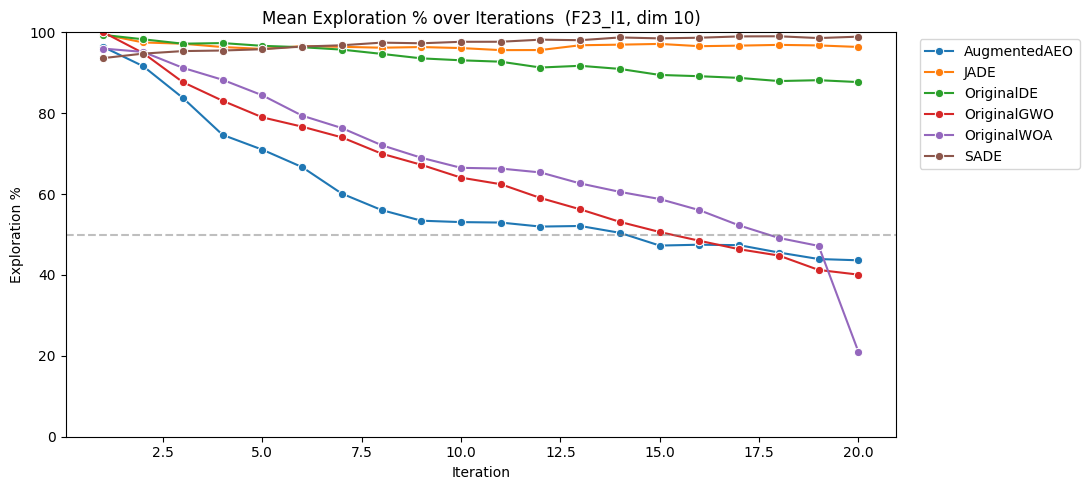

In [25]:
mean_curves = data.groupby(['algorithm', 'iteration'])['exploration'].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=mean_curves, x='iteration', y='exploration', hue='algorithm', marker='o')
plt.title(f'Mean Exploration % over Iterations  (F{F}_I{I}, dim {DIM})')
plt.xlabel('Iteration'); plt.ylabel('Exploration %')
plt.ylim(0, 100)
plt.axhline(50, color='gray', linestyle='--', alpha=0.5)  # explore/exploit balance line
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Exploration vs exploitation for a single algorithm (with run spread)
Picks one algorithm and shows exploration and exploitation as complementary bands,
with the shaded region showing variability across runs (min-max).

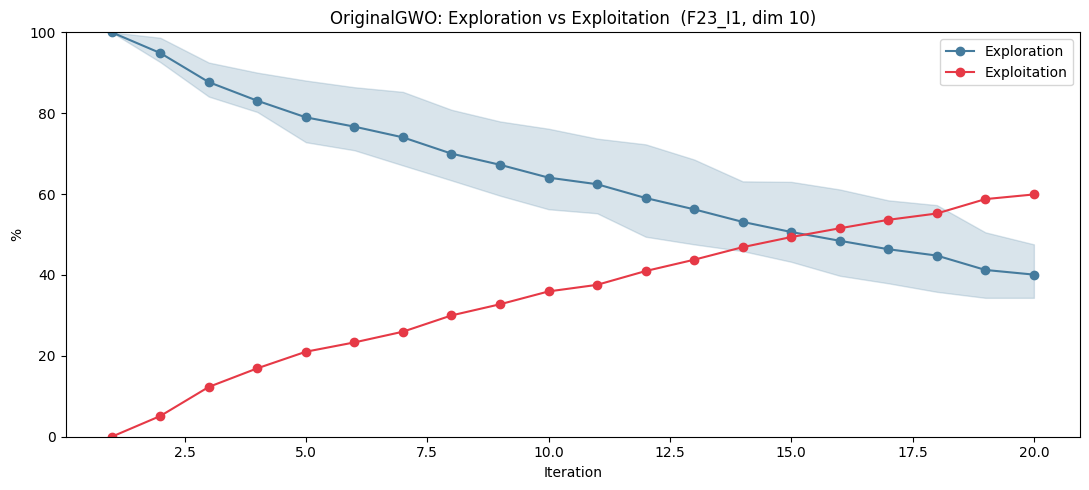

In [27]:
ALG_ONE = ALGOS[4]
sub = data[data['algorithm'] == ALG_ONE]

agg = sub.groupby('iteration').agg(
    expl_mean=('exploration', 'mean'),
    expl_min=('exploration', 'min'),
    expl_max=('exploration', 'max'),
    exploit_mean=('exploitation', 'mean'),
).reset_index()

plt.figure(figsize=(11, 5))
plt.plot(agg['iteration'], agg['expl_mean'], color='#457b9d', label='Exploration', marker='o')
plt.fill_between(agg['iteration'], agg['expl_min'], agg['expl_max'], color='#457b9d', alpha=0.2)
plt.plot(agg['iteration'], agg['exploit_mean'], color='#e63946', label='Exploitation', marker='o')
plt.title(f'{ALG_ONE}: Exploration vs Exploitation  (F{F}_I{I}, dim {DIM})')
plt.xlabel('Iteration'); plt.ylabel('%')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Pairwise exploration difference (the metric itself)
For each pair of the selected algorithms, the mean absolute difference in
exploration % across iterations (averaged over runs) - i.e. exactly the
`Mean_exploration_difference` metric, shown as a heatmap. Low = the two
algorithms balance explore/exploit very similarly.

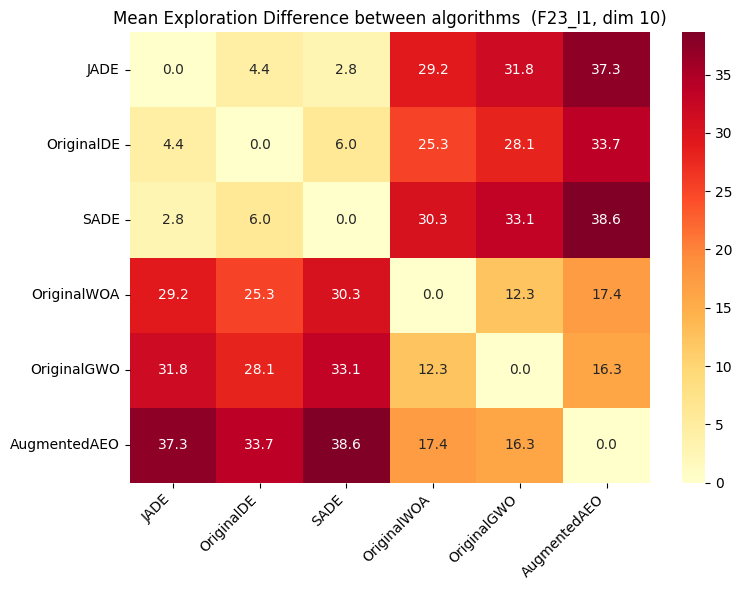

In [28]:
from itertools import combinations

# per-run curves keyed by (alg, run)
def expl_curve(alg, run):
    s = data[(data['algorithm']==alg) & (data['run']==run)].sort_values('iteration')
    return s['exploration'].to_numpy()

# build symmetric matrix of mean-abs-difference, averaged over runs (seed-paired)
n = len(ALGOS)
M = pd.DataFrame(np.zeros((n, n)), index=ALGOS, columns=ALGOS)
for a1, a2 in combinations(ALGOS, 2):
    per_run = []
    for r in RUNS:
        e1, e2 = expl_curve(a1, r), expl_curve(a2, r)
        if len(e1) == len(e2) and len(e1) > 0:
            per_run.append(np.abs(e1 - e2).mean())
    val = np.mean(per_run) if per_run else np.nan
    M.loc[a1, a2] = val
    M.loc[a2, a1] = val

plt.figure(figsize=(8, 6))
sns.heatmap(M, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title(f'Mean Exploration Difference between algorithms  (F{F}_I{I}, dim {DIM})')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Diversity (raw, un-normalized) over iterations
Exploration % is diversity normalized by the run's max. The raw diversity curve
shows the actual magnitude of population spread - useful to see whether an
algorithm's population physically contracts fast or slowly, before normalization
flattens everything onto 0-100.

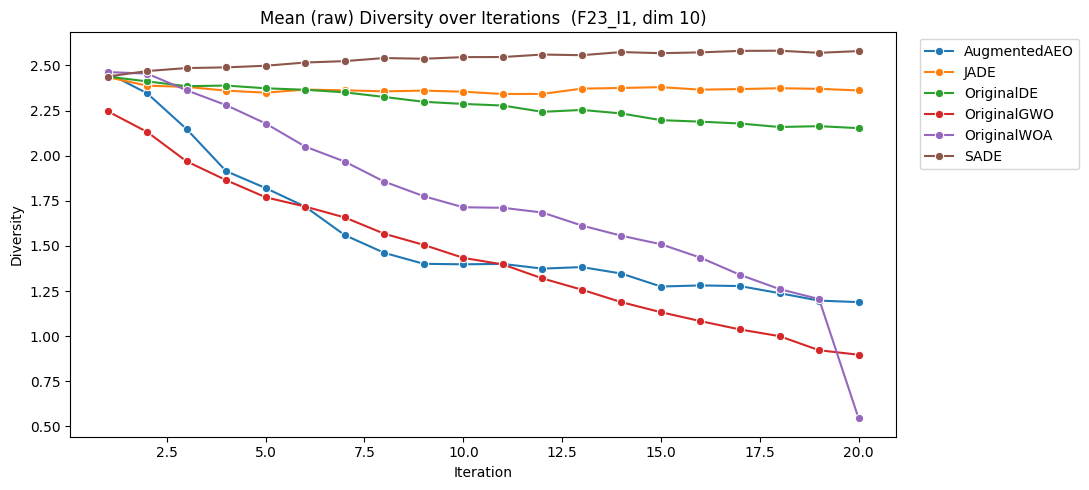

In [29]:
div_curves = data.groupby(['algorithm', 'iteration'])['diversity'].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=div_curves, x='iteration', y='diversity', hue='algorithm', marker='o')
plt.title(f'Mean (raw) Diversity over Iterations  (F{F}_I{I}, dim {DIM})')
plt.xlabel('Iteration'); plt.ylabel('Diversity')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()